# Exploring `base_network.py` outputs

This jupyter notebook analyse the `base_network.py` **outputs**.

The `pypsa-earth/Snakefile` explicitly list in the **rule** what goes into the function `base_network.py` and what goes out (`networks/base.nc`). When inputs are commented out (#) than they are currently not considered. Maybe you want to delete them, make them run or develop new features? What can be observed from the inputs is that the script creates a connected network topology with the network data and shapes of the region.

```
rule base_network:
    input:
        osm_buses="data/base_network/africa_all_buses_build_network.csv",
        osm_lines="data/base_network/africa_all_lines_build_network.csv",
        country_shapes='resources/country_shapes.geojson',
        offshore_shapes='resources/offshore_shapes.geojson',
        # eg = ENTSO-E Gridkit
        # eg_buses='data/entsoegridkit/buses.csv',
        # eg_lines='data/entsoegridkit/lines.csv',
        # eg_links='data/entsoegridkit/links.csv',
        # eg_converters='data/entsoegridkit/converters.csv',
        # eg_transformers='data/entsoegridkit/transformers.csv',
        # parameter_corrections='data/parameter_corrections.yaml',
        # links_p_nom='data/links_p_nom.csv',
        # links_tyndp='data/links_tyndp.csv',
        # africa_shape='resources/africa_shape.geojson'
    output:
        "networks/base.nc",
    log:
        "logs/base_network.log",
    benchmark:
        "benchmarks/base_network"
    threads: 1
    resources:
        mem=500,
    script:
        "scripts/base_network.py"
```

Before analysing the outputs of add_electricity.py check that:
- `pypsa-earth` environment (/kernel) in jupyter notebook  is active and updated
- root folder where pypsa-earth is installed is named "pypsa-earth"
- or rename the below `sets_path_to_root("<folder_name>")` accordingly

In [1]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

A jupyter notebook requires the user to import all they need. So we need to import all the required dependencies from the `pypsa-earth` environment:

In [2]:
import logging
import os

import pypsa
import yaml
import pandas as pd
import geopandas as gpd
import geoviews as gv
import hvplot.pandas
import numpy as np
import scipy as sp
import networkx as nx
import matplotlib as plt

from scipy.sparse import csgraph
from itertools import product

from shapely.geometry import Point, LineString
import shapely, shapely.prepared, shapely.wkt
import shapely
import warnings
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) # Ignore Shapely warnings

logger = logging.getLogger(__name__)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

## Network analysis

Now let's import the output file which should be in i.e. `~/pypsa-earth/networks/base.nc`. 

Note: If you don't have the /elec.nc file yet in your folder structure, you could try to generate it from the terminal. In this case set the path so that you are located at `~/pypsa-earth`. Once you are there, use the command:
```
snakemake -j 1 networks/base.nc
```
Note that this is something you can to for any other rule to generate it's outputs `snakemake -j 1 <output of rule>`

In [3]:
# network_path = os.getcwd() + "/pypsa-earth/networks/base.nc"
network_path = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-sec-netZero-2050/base.nc"
# network_path = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-el-netZero-2030-12H/elec_s_48_ec_lcopt_Co2L-12H.nc"
n = pypsa.Network(network_path)
n

INFO:pypsa.io:Imported network base.nc has buses, lines, transformers


PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 539
 - Line: 732
 - Transformer: 123
Snapshots: 8760

You might be interested to see what's in the Network Common Data Form or NetCDF (.nc) file. To assess that we use **xarray**

In [4]:
import xarray as xr

path = network_path
network_data = xr.open_dataset(path)
#network_data

In [5]:
n.buses.head(2)

,v_nom,symbol,under_construction,tag_substation,tag_area,lon,lat,country,substation_lv,x,y,substation_off,type,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
Bus,,,,,,,,,,,,,,,,,,,,,
0,60.0,substation,False,transmission,0.0,-1.8639,35.0863,DZ,True,-1.8639,35.0863,True,,AC,,1.0,0.0,inf,PQ,,
1,220.0,substation,False,transmission,0.0,-1.8629,35.0873,DZ,False,-1.8629,35.0873,True,,AC,,1.0,0.0,inf,PQ,,


Example to check the input:

<AxesSubplot:>

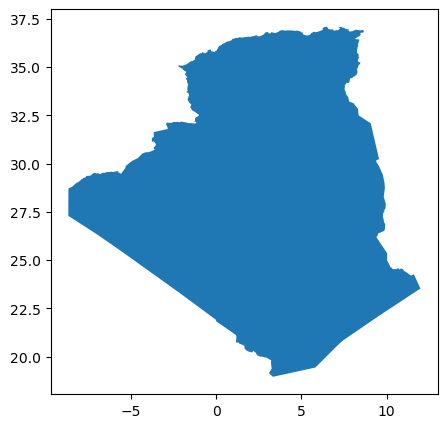

In [6]:
regions = (
    # os.getcwd() + "/pypsa-earth/resources/shapes/country_shapes.geojson"
    os.getcwd() + "/pypsa-earth/resources/DZA-48-GADM-sec-netZero-2050/shapes/country_shapes.geojson"
)  # path of the input as shown in the Snakefile
gpd.read_file(regions).plot(figsize=(5,5))

That's how the raw data looks like:

In [7]:
gpd.read_file(regions)

,name,geometry
0,DZ,"POLYGON ((2.84187 36.7369, 2.83999 36.76346, 2.87887 36.76781, 2.9..."


Checking which countries are considered:

In [8]:
n.buses["country"].unique()

array(['DZ'], dtype=object)

Looking at the lines you find out that some of the names at the end of the pandadataframe are quite long. These are articifial created lines that create a connected network topology:

In [9]:
n.lines.head(2)

,num_parallel,v_nom,bus0,bus1,length,dc,country,geometry,bounds,carrier,type,s_max_pu,s_nom,underwater_fraction,x,r,g,b,s_nom_mod,s_nom_extendable,s_nom_min,s_nom_max,capital_cost,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
Line,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2.0,220.0,102,292,17.211388,False,DZ,"MULTILINESTRING ((3.1185 36.6986, 3.134462600000012 36.69958219999...","MULTIPOINT ((3.1185 36.6986), (3.1344626000000115 36.6995821999997...",AC,Al/St 240/40 2-bundle 220.0,0.7,983.112038,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,inf,0.0,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,220.0,141,146,22.628348,False,DZ,"MULTILINESTRING ((3.141550900000011 36.59763069999977, 3.141550900...","MULTIPOINT ((3.141550900000011 36.59763069999977), (3.141550900000...",AC,Al/St 240/40 2-bundle 220.0,0.7,491.556019,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,inf,0.0,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Check hv.plot (need to be fixed)

In [10]:
# Issue probably with ["geometry"]
n.lines["geometry"].head(2)  # .apply(wkt.loads)

Line
0    MULTILINESTRING ((3.1185 36.6986, 3.134462600000012 36.69958219999...
1    MULTILINESTRING ((3.141550900000011 36.59763069999977, 3.141550900...
Name: geometry, dtype: object

In [11]:
from shapely import wkt

lines = n.lines
lines["geometry"] = lines["geometry"].apply(wkt.loads)
lines = gpd.GeoDataFrame(lines, crs="epsg:4326")

buses = n.buses
buses["geometry"] = gpd.points_from_xy(buses.lon, buses.lat)
buses = gpd.GeoDataFrame(buses, crs="epsg:4326")

In [12]:
#lines = lines[lines["country"] == "DZ"]
#buses = buses[buses["country"] == "DZ"]

basa_network = buses.hvplot(
    geo=True,
    size=10,  # buses["tag_area"]**(0.5)/10,
    frame_height=750,
    alpha=0.4,
    tiles="CartoLight",
    hover_cols=["bus_id"],
    color="orange",
) * lines.hvplot(geo=True, alpha=0.4, hover_cols=["line_id"]).opts(
    active_tools=["pan", "wheel_zoom"]
)
display(basa_network) # show the plot in the notebook
#hvplot.save(basa_network, "documentation/base_network_buses_lines.html");

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]

# Look at network after add_electricity

Topology does not change; but carriers, generators and loads are added

In [20]:
# network_path = os.getcwd() + "/pypsa-earth/networks/base.nc"
network_path_el = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-sec-netZero-2050/elec.nc"
# network_path = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-el-netZero-2030-12H/elec_s_48_ec_lcopt_Co2L-12H.nc"
n_el = pypsa.Network(network_path_el)
n_el

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 539
 - Carrier: 15
 - Generator: 1037
 - Line: 732
 - Load: 416
 - StorageUnit: 1
 - Transformer: 123
Snapshots: 8760

In [21]:
from shapely import wkt

lines = n_el.lines
lines["geometry"] = lines["geometry"].apply(wkt.loads)
lines = gpd.GeoDataFrame(lines, crs="epsg:4326")

buses = n_el.buses
buses["geometry"] = gpd.points_from_xy(buses.lon, buses.lat)
buses = gpd.GeoDataFrame(buses, crs="epsg:4326")

In [22]:
#lines = lines[lines["country"] == "DZ"]
#buses = buses[buses["country"] == "DZ"]

basa_network = buses.hvplot(
    geo=True,
    size=10,  # buses["tag_area"]**(0.5)/10,
    frame_height=750,
    alpha=0.4,
    tiles="CartoLight",
    hover_cols=["bus_id"],
    color="orange",
) * lines.hvplot(geo=True, alpha=0.4, hover_cols=["line_id"]).opts(
    active_tools=["pan", "wheel_zoom"]
)
display(basa_network) # show the plot in the notebook
#hvplot.save(basa_network, "documentation/base_network_buses_lines.html");

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]

# Look at network after simplify_network

The isolated lines are lost now. Only the substation without any lines in the South remains.
It seems like all lines that are either..
* only connected to one substation
* not connected to the rest of the network 

are deleted

In [23]:
# network_path = os.getcwd() + "/pypsa-earth/networks/base.nc"
network_path_s = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-sec-netZero-2050/elec_s.nc"
# network_path = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-el-netZero-2030-12H/elec_s_48_ec_lcopt_Co2L-12H.nc"
n_s = pypsa.Network(network_path_s)
n_s

INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, loads, storage_units


PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 416
 - Carrier: 15
 - Generator: 1037
 - Line: 732
 - Load: 416
 - StorageUnit: 1
Snapshots: 8760

In [24]:
from shapely import wkt

lines = n_s.lines
lines["geometry"] = lines["geometry"].apply(wkt.loads)
lines = gpd.GeoDataFrame(lines, crs="epsg:4326")

buses = n_s.buses
buses["geometry"] = gpd.points_from_xy(buses.lon, buses.lat)
buses = gpd.GeoDataFrame(buses, crs="epsg:4326")


#lines = lines[lines["country"] == "DZ"]
#buses = buses[buses["country"] == "DZ"]

basa_network = buses.hvplot(
    geo=True,
    size=10,  # buses["tag_area"]**(0.5)/10,
    frame_height=750,
    alpha=0.4,
    tiles="CartoLight",
    hover_cols=["bus_id"],
    color="orange",
) * lines.hvplot(geo=True, alpha=0.4, hover_cols=["line_id"]).opts(
    active_tools=["pan", "wheel_zoom"]
)
display(basa_network) # show the plot in the notebook
#hvplot.save(basa_network, "documentation/base_network_buses_lines.html");

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]

# Look at network after cluster_network

Number of buses and lines (but also generator and loads) is greatly reduced.
 
But now we see that we are only using one cluster (North-West; where no substation is placed) and have an equal amount of loads and buses. Great!

In [25]:
# network_path = os.getcwd() + "/pypsa-earth/networks/base.nc"
network_path_c = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-sec-netZero-2050/elec_s_12.nc"
# network_path = os.getcwd() + "/pypsa-earth/networks/DZA-48-GADM-el-netZero-2030-12H/elec_s_48_ec_lcopt_Co2L-12H.nc"
n_c = pypsa.Network(network_path_c)
n_c

INFO:pypsa.io:Imported network elec_s_12.nc has buses, carriers, generators, lines, loads, storage_units


PyPSA Network
Components:
 - Bus: 36
 - Carrier: 15
 - Generator: 101
 - Line: 31
 - Load: 36
 - StorageUnit: 1
Snapshots: 8760

In [26]:
from shapely import wkt

lines = n_c.lines
lines["geometry"] = lines["geometry"].apply(wkt.loads)
lines = gpd.GeoDataFrame(lines, crs="epsg:4326")

buses = n_c.buses
buses["geometry"] = gpd.points_from_xy(buses.lon, buses.lat)
buses = gpd.GeoDataFrame(buses, crs="epsg:4326")


#lines = lines[lines["country"] == "DZ"]
#buses = buses[buses["country"] == "DZ"]

basa_network = buses.hvplot(
    geo=True,
    size=10,  # buses["tag_area"]**(0.5)/10,
    frame_height=750,
    alpha=0.4,
    tiles="CartoLight",
    hover_cols=["bus_id"],
    color="orange",
) * lines.hvplot(geo=True, alpha=0.4, hover_cols=["line_id"]).opts(
    active_tools=["pan", "wheel_zoom"]
)
display(basa_network) # show the plot in the notebook
#hvplot.save(basa_network, "documentation/base_network_buses_lines.html");

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]